# WKB mode-function matching
Solves X'' + f1 X' + (k^2 f3 + f2) X = 0 by brute force up to eta_wkb, then continues analytically (WKB). Validated here against the exact closed-form RD solution.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../core'))
import numpy as np
import matplotlib.pyplot as plt
import plotstyle; plotstyle.use_latex()
import modes
import background_rd as rd
import jax.numpy as jnp

## Find eta_wkb and match the scalar mode Phi
eta_wkb is the smallest eta beyond which k^2 f3 safely dominates f2, f1', f1^2 (see modes.find_eta_wkb).

In [2]:
k = 1e3       # external wavenumber [Mpc^-1]
eta_in, eta_hi = 0.01 / k, 400.0 / k
match = modes.match_mode(k, rd.f1_Phi, rd.f2_Phi, rd.f3_Phi, eta_in, 1.0, 0.0, eta_hi)
print(f'eta_wkb = {match.eta_wkb:.4e}  (eta_star = {match.eta_star:.4e}, eta_hi = {eta_hi:.4e})')

eta_wkb = 2.6855e-01  (eta_star = 1.3427e-01, eta_hi = 4.0000e-01)


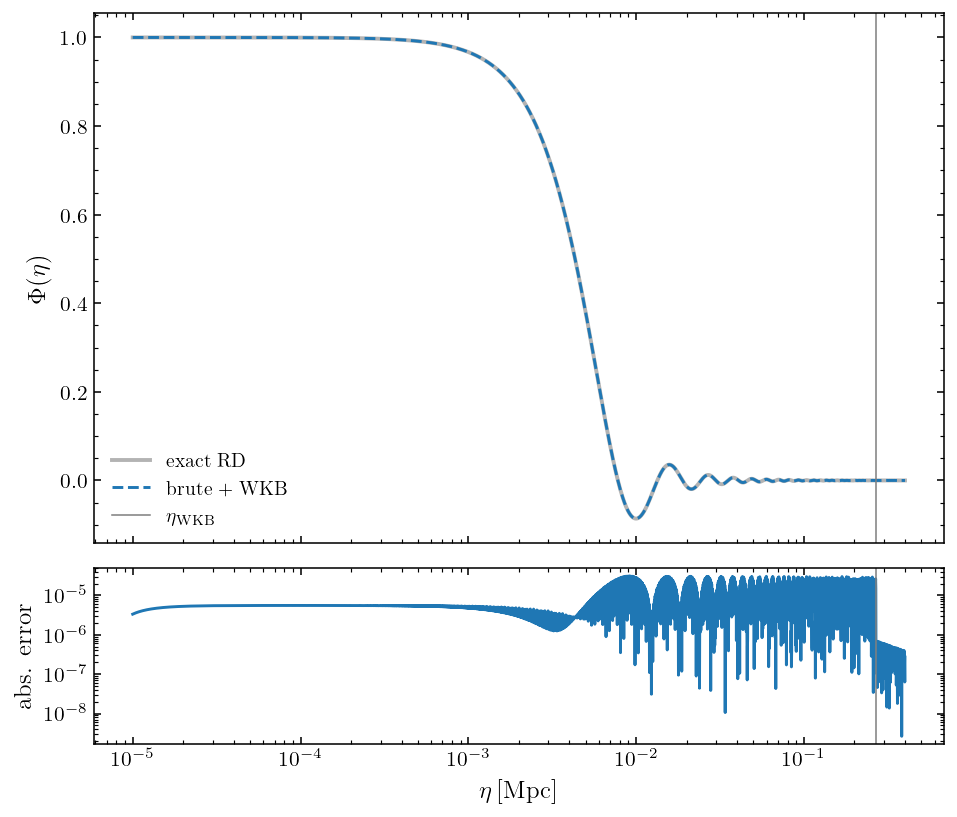

In [3]:
eta_grid = np.geomspace(eta_in, eta_hi, 4000)
X, Xp = modes.eval_mode(match, eta_grid)
X_exact = np.asarray(rd.Phi_analytic(jnp.asarray(eta_grid), k))

fig, axes = plt.subplots(2, 1, figsize=(7, 6), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
axes[0].plot(eta_grid, X_exact, label='exact RD', lw=2, color='0.7')
axes[0].plot(eta_grid, X, label='brute + WKB', ls='--')
axes[0].axvline(match.eta_wkb, color='gray', lw=0.8, label=r'$\eta_{\rm WKB}$')
axes[0].set_xscale('log'); axes[0].set_ylabel(r'$\Phi(\eta)$'); axes[0].legend()
axes[1].plot(eta_grid, np.abs(X - X_exact) / np.abs(X_exact).max())
axes[1].axvline(match.eta_wkb, color='gray', lw=0.8)
axes[1].set_yscale('log'); axes[1].set_xlabel(r'$\eta\,[\mathrm{Mpc}]$'); axes[1].set_ylabel('abs. error')
plt.tight_layout(); plt.show()

## Same check for the tensor Green's function g1

g1 eta_wkb = 2.0000e-05


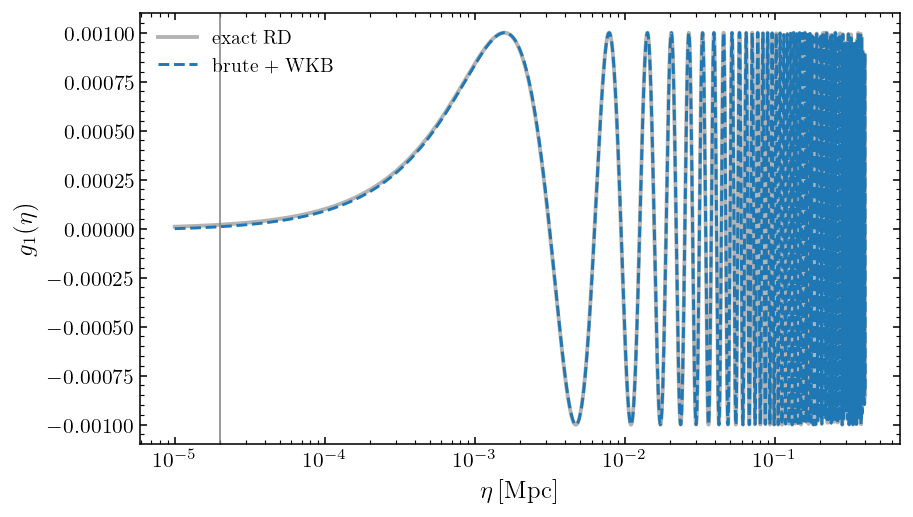

In [4]:
g1_match = modes.match_mode(k, rd.f1_g, rd.f2_g, rd.f3_g, eta_in, 0.0, 1.0, eta_hi)
g1, _ = modes.eval_mode(g1_match, eta_grid)
g1_exact = np.asarray(rd.g1_analytic(jnp.asarray(eta_grid), k))
print(f'g1 eta_wkb = {g1_match.eta_wkb:.4e}')
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(eta_grid, g1_exact, label='exact RD', lw=2, color='0.7')
ax.plot(eta_grid, g1, label='brute + WKB', ls='--')
ax.axvline(g1_match.eta_wkb, color='gray', lw=0.8)
ax.set_xscale('log'); ax.set_xlabel(r'$\eta\,[\mathrm{Mpc}]$'); ax.set_ylabel(r'$g_1(\eta)$'); ax.legend()
plt.show()